In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/bpm-and-hrv-dataset-for-stress-detection/bpm_dataset_5000.xls


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize']=[14,5]

In [3]:
# !pip install python-calamine

In [4]:
# df=pd.read_excel('/kaggle/input/bpm-and-hrv-dataset-for-stress-detection/bpm_dataset_5000.xls',engine='calamine')

In [5]:
with open('/kaggle/input/bpm-and-hrv-dataset-for-stress-detection/bpm_dataset_5000.xls','r') as f:
    data=f.read()

In [6]:
headers = data[0:30]
headers

'bpm,rr_mean,rr_std,rmssd,label'

In [7]:
print(data[30:61])


72.44,0.793,0.106,0.085,normal


In [8]:
print(data[61:92])


94.71,0.627,0.166,0.121,stress


In [9]:
print(data[92:123])


64.94,0.818,0.116,0.047,normal


In [10]:
data = data.replace("\n",",")
labels = data[0:30]

In [11]:
labels

'bpm,rr_mean,rr_std,rmssd,label'

In [12]:
data = data[31:]


In [13]:
len(data)

150400

In [14]:
data=data.split(",")

In [15]:
data[0:5]

['72.44', '0.793', '0.106', '0.085', 'normal']

In [16]:
data=data[0:-1]

In [17]:
data_new=[]
for i in range(0,len(data),5):
    data_new.append(data[i:i+5])

In [18]:
labels=labels.split(",")
labels

['bpm', 'rr_mean', 'rr_std', 'rmssd', 'label']

In [19]:
df = pd.DataFrame(data_new,columns=labels)
df

,bpm,rr_mean,rr_std,rmssd,label
0,72.44,0.793,0.106,0.085,normal
1,94.71,0.627,0.166,0.121,stress
2,64.94,0.818,0.116,0.047,normal
3,61.37,0.878,0.075,0.038,calm
4,75.24,0.932,0.061,0.035,calm
...,...,...,...,...,...
4995,89.5,0.487,0.168,0.138,stress
4996,69.14,0.9,0.045,0.027,calm
4997,88.25,0.568,0.216,0.14,stress
4998,63.4,0.923,0.043,0.042,calm


In [20]:
df.shape

(5000, 5)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   bpm      5000 non-null   object
 1   rr_mean  5000 non-null   object
 2   rr_std   5000 non-null   object
 3   rmssd    5000 non-null   object
 4   label    5000 non-null   object
dtypes: object(5)
memory usage: 195.4+ KB


In [22]:
for i in df.columns[0:-1]:
    df[i]=df[i].astype("float")

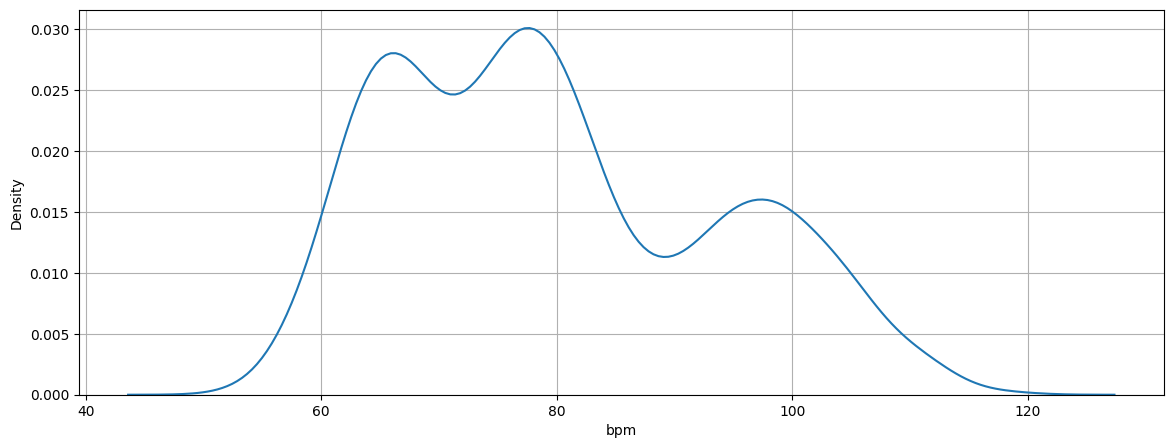

In [23]:
sns.kdeplot(x=df['bpm'])
plt.grid()
plt.show()

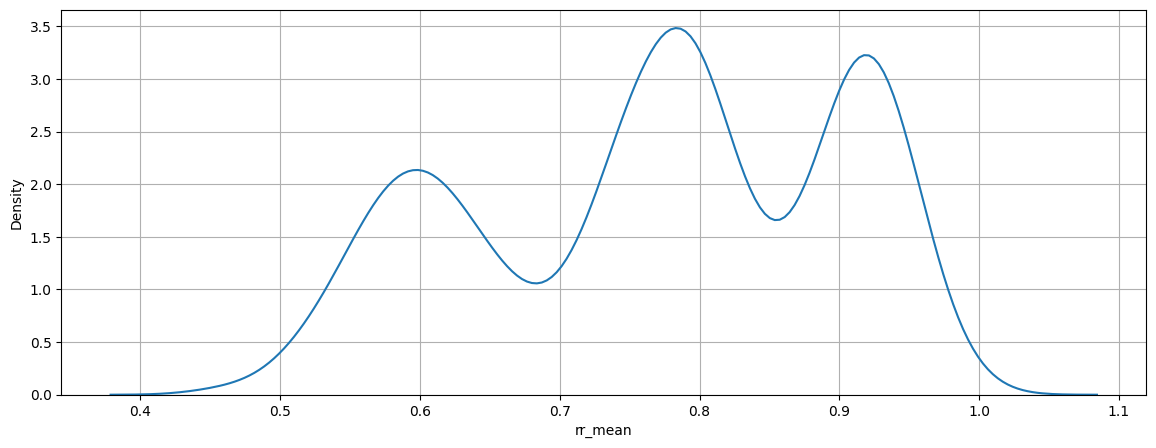

In [24]:
sns.kdeplot(x=df['rr_mean'])
plt.grid()
plt.show()

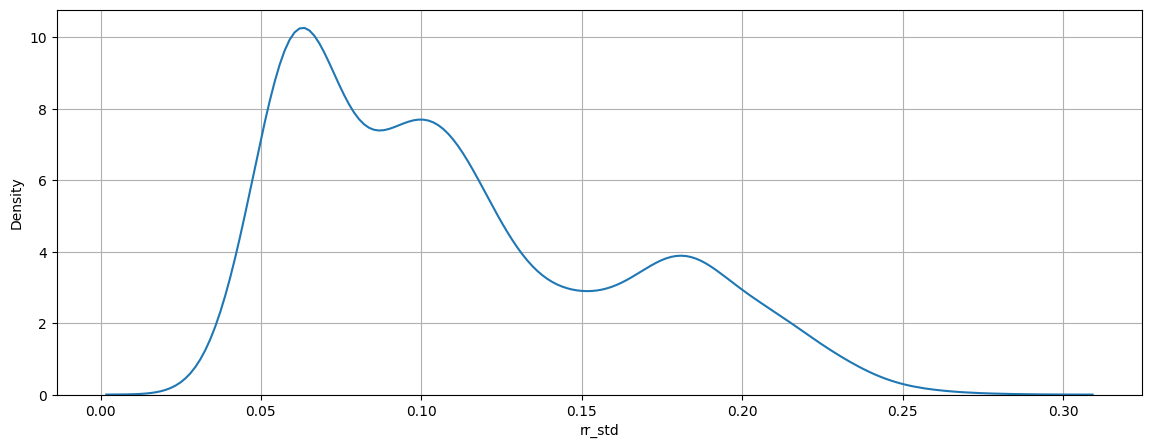

In [25]:
sns.kdeplot(x=df['rr_std'])
plt.grid()
plt.show()

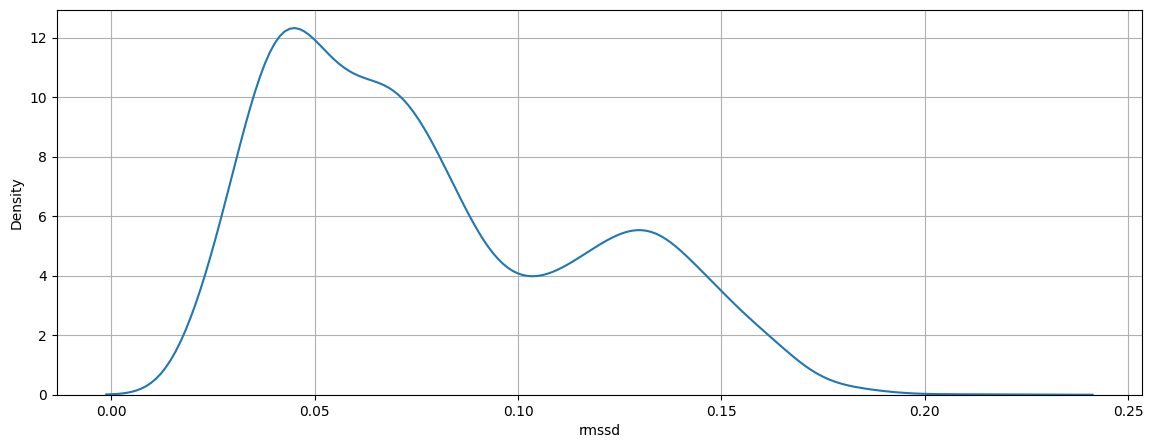

In [26]:
sns.kdeplot(x=df['rmssd'])
plt.grid()
plt.show()

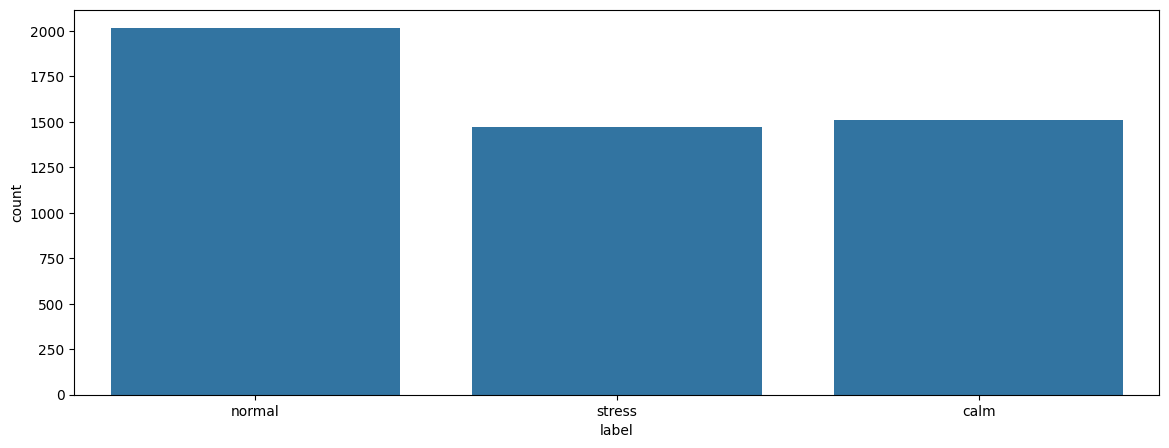

In [27]:
sns.countplot(x=df['label'])
plt.show()

In [28]:
df

,bpm,rr_mean,rr_std,rmssd,label
0,72.44,0.793,0.106,0.085,normal
1,94.71,0.627,0.166,0.121,stress
2,64.94,0.818,0.116,0.047,normal
3,61.37,0.878,0.075,0.038,calm
4,75.24,0.932,0.061,0.035,calm
...,...,...,...,...,...
4995,89.50,0.487,0.168,0.138,stress
4996,69.14,0.900,0.045,0.027,calm
4997,88.25,0.568,0.216,0.140,stress
4998,63.40,0.923,0.043,0.042,calm


In [29]:
y=df['label']
x=df.drop('label',axis=1)

<Axes: >

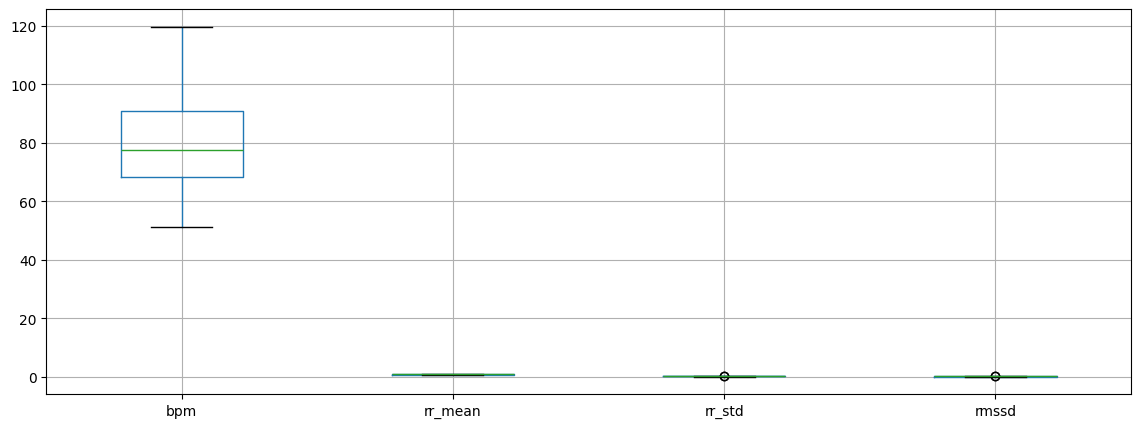

In [30]:
x.boxplot()

In [31]:
from sklearn.preprocessing import LabelEncoder

In [32]:
le = LabelEncoder()

In [33]:
y=le.fit_transform(y)
y

array([1, 2, 1, ..., 2, 0, 1])

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.30,random_state=42)

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,recall_score,f1_score,precision_score

In [37]:
rf=RandomForestClassifier()

In [38]:
rf.fit(xtrain,ytrain)

RandomForestClassifier()

In [39]:
print("The accuracy score for train set is",accuracy_score(ytrain,rf.predict(xtrain)))
print("The precision score for train set is",precision_score(ytrain,rf.predict(xtrain),average='weighted'))
print("The recall score for train set is",recall_score(ytrain,rf.predict(xtrain),average='weighted'))
print("The f1 score for train set is",f1_score(ytrain,rf.predict(xtrain),average='weighted'))
print("")
print("The accuracy score for test set is",accuracy_score(ytest,rf.predict(xtest)))
print("The precision score for test set is",precision_score(ytest,rf.predict(xtest),average='weighted'))
print("The recall score for test set is",recall_score(ytest,rf.predict(xtest),average='weighted'))
print("The f1 score for test set is",f1_score(ytest,rf.predict(xtest),average='weighted'))

The accuracy score for train set is 1.0
The precision score for train set is 1.0
The recall score for train set is 1.0
The f1 score for train set is 1.0

The accuracy score for test set is 0.9993333333333333
The precision score for test set is 0.9993348982785603
The recall score for test set is 0.9993333333333333
The f1 score for test set is 0.9993334631807258
